In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
RANDOM_STATE = 777

 Переходим к бинарной классификации. Мы объединяем класс 1 (преддиабет) и класс 2 (диабет) в единую категорию «Группа риска». Это обусловлено тем, что для первичного скрининга важно отделить здоровых людей от тех, кому требуется дообследование.

In [8]:
df = pd.read_csv('..\\data\\processed\\diabetes_012_health_indicators_BRFSS2015_processed.csv')

df['Diabetes_Binary'] = df['Diabetes_012'].replace({2: 1})

X = df.drop(['Diabetes_012', 'Diabetes_Binary'], axis=1)
y = df['Diabetes_Binary']

Утечка данных исключена, так как: 
1) Сплит сделан до любого обучения/скалирования. 
2) Данные являются кросс-секционными (опрос), временная зависимость отсутствует

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} строк (Класс 1: {y_train.sum()})")
print(f"Val:   {X_val.shape[0]} строк (Класс 1: {y_val.sum()})")
print(f"Test:  {X_test.shape[0]} строк (Класс 1: {y_test.sum()})")

Train: 177576 строк (Класс 1: 27984)
Val:   38052 строк (Класс 1: 5996)
Test:  38052 строк (Класс 1: 5997)


### Выбор метрик качества
В условиях дисбаланса классов Accuracy неинформативна. 
В качестве основных метрик мы выбираем:
1. **F1-Score** — для баланса между точностью и полнотой на целевом классе (Группа риска).
2. **ROC-AUC** — для оценки способности модели ранжировать пациентов по степени риска.
3. **Recall (Полнота)** — критически важна для медицины, так как цена пропуска больного выше цены ложноположительного диагноза.

In [10]:
def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    print(f"--- Оценка модели: {model_name} ---")
    print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
    print(classification_report(y_val, y_pred, target_names=['0: Здоров', '1: Группа риска']))
    
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Здоров', 'Риск'],
                yticklabels=['Здоров', 'Риск'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()


Для линейных моделей критически важно масштабировать признаки, иначе признаки с большими значениями (например, ИМТ) «задавят» бинарные фичи.

--- Оценка модели: Logistic Regression (Baseline) ---
ROC-AUC: 0.8177
                 precision    recall  f1-score   support

      0: Здоров       0.94      0.72      0.82     32056
1: Группа риска       0.34      0.76      0.47      5996

       accuracy                           0.73     38052
      macro avg       0.64      0.74      0.64     38052
   weighted avg       0.85      0.73      0.76     38052



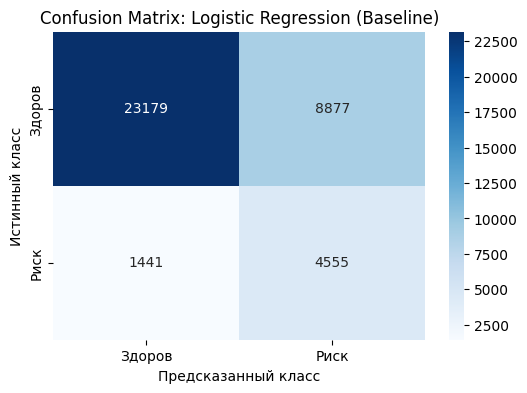

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    random_state=RANDOM_STATE
)
lr_model.fit(X_train_scaled, y_train)

evaluate_model(lr_model, X_val_scaled, y_val, "Logistic Regression (Baseline)")

1. Общая эффективность (ROC-AUC) \
Модель показала достаточно высокий уровень ROC-AUC (0.8177). Для простой линейной модели это отличный результат, который говорит о том, что даже на основе анкетных данных можно с высокой вероятностью отличить здорового человека от представителя группы риска.

2. Анализ полноты (Recall) — приоритет в медицине \
Самым важным достижением бейзлайна является Recall для группы риска (0.76). Это означает, что модель успешно выявляет 76% людей, имеющих преддиабет или диабет. В задачах медицинского скрининга высокая полнота является приоритетом, так как цена ошибки при пропуске заболевания гораздо выше, чем цена дополнительного обследования здорового человека.

3. Анализ точности (Precision) и дисбаланса \
Низкая точность (0.34) для группы риска указывает на большое количество ложноположительных срабатываний. На каждого реально больного модель выдает примерно двух здоровых людей с подозрением на риск. Это ожидаемый эффект при использовании class_weight='balanced' на несбалансированных данных: модель намеренно становится более «подозрительной», чтобы не пропустить болезнь.

Логистическая регрессия установила сильную планку по ROC-AUC, но имеет проблемы с точностью (высокий уровень ложных тревог). В следующей части проекта мы попробуем использовать градиентный бустинг (CatBoost, XGBoost, LightGBM), чтобы за счет учета нелинейных зависимостей между признаками поднять точность (Precision), сохранив при этом высокий уровень полноты (Recall